# EDA — `lexdata.hechos_vif`
Violencia Intrafamiliar · INMLCF + Policía SIEDCO

## 0 · Setup

In [1]:
import sys
!{sys.executable} -m pip install sqlalchemy python-dotenv


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install psycopg2-binary


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ── Dependencias ────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

# ── Estilo ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ── Conexión PostgreSQL via .env ─────────────────────────────────────────────
load_dotenv()  # carga .env desde la carpeta del notebook
DB_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
engine = create_engine(DB_URL)

def sql(query, **kwargs):
    with engine.connect() as con:
        return pd.read_sql(text(query), con, **kwargs)

print("✅ Conexión lista:", DB_URL.split("@")[-1])


✅ Conexión lista: localhost:5432/lexdata


## 1 · Vista general

In [4]:
df = sql("SELECT * FROM lexdata.hechos_vif")
print(f"Shape: {df.shape}")
print(f"Periodo: {df['anio'].min()} – {df['anio'].max()}")
df.head()


Shape: (905661, 10)
Periodo: 2020 – 2025


,id,municipio,departamento,anio,cantidad,tipo_ciclo,fuente,created_at,sexo_de_la_victima,escolaridad
0,1,PEREIRA,RISARALDA,2020,1.0,VIF,INMLCF — VIF Forense,2026-05-25 14:16:57.902092,None,None
1,2,VILLAVICENCIO,META,2020,1.0,VIF,INMLCF — VIF Forense,2026-05-25 14:16:57.902092,None,None
2,3,VILLAVICENCIO,META,2020,1.0,VIF,INMLCF — VIF Forense,2026-05-25 14:16:57.902092,None,None
3,4,VILLAVICENCIO,META,2020,1.0,VIF,INMLCF — VIF Forense,2026-05-25 14:16:57.902092,None,None
4,5,VILLAVICENCIO,META,2020,1.0,VIF,INMLCF — VIF Forense,2026-05-25 14:16:57.902092,None,None


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905661 entries, 0 to 905660
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  905661 non-null  int64         
 1   municipio           905649 non-null  object        
 2   departamento        905661 non-null  object        
 3   anio                905661 non-null  int64         
 4   cantidad            905661 non-null  float64       
 5   tipo_ciclo          905661 non-null  object        
 6   fuente              905661 non-null  object        
 7   created_at          905661 non-null  datetime64[ns]
 8   sexo_de_la_victima  0 non-null       object        
 9   escolaridad         0 non-null       object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 69.1+ MB


In [6]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,905661.0,NaN,NaN,NaN,452831.0,1.0,226416.0,452831.0,679246.0,905661.0,261441.95541
municipio,905649,1060,"BOGOTA, D.C.",77526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departamento,905661,38,ANTIOQUIA,120645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anio,905661.0,NaN,NaN,NaN,2022.608976,2020.0,2021.0,2023.0,2024.0,2025.0,1.614887
cantidad,905661.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0
tipo_ciclo,905661,1,VIF,905661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuente,905661,2,Policia SIEDCO — VIF,608895,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,905661,NaN,NaN,NaN,2026-05-25 14:20:31.611246336,2026-05-25 14:16:57.902092,2026-05-25 14:17:03.895408896,2026-05-25 14:21:38.532329984,2026-05-25 14:22:52.623314944,2026-05-25 14:22:57.883782,NaN
sexo_de_la_victima,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
escolaridad,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2 · Nulos y calidad

In [7]:
nulos = df.isnull().sum().rename("nulos")
pct   = (df.isnull().mean() * 100).round(2).rename("pct_%")
display(pd.concat([nulos, pct], axis=1).query("nulos > 0"))


,nulos,pct_%
municipio,12,0.0
sexo_de_la_victima,905661,100.0
escolaridad,905661,100.0


## 3 · Distribución por año

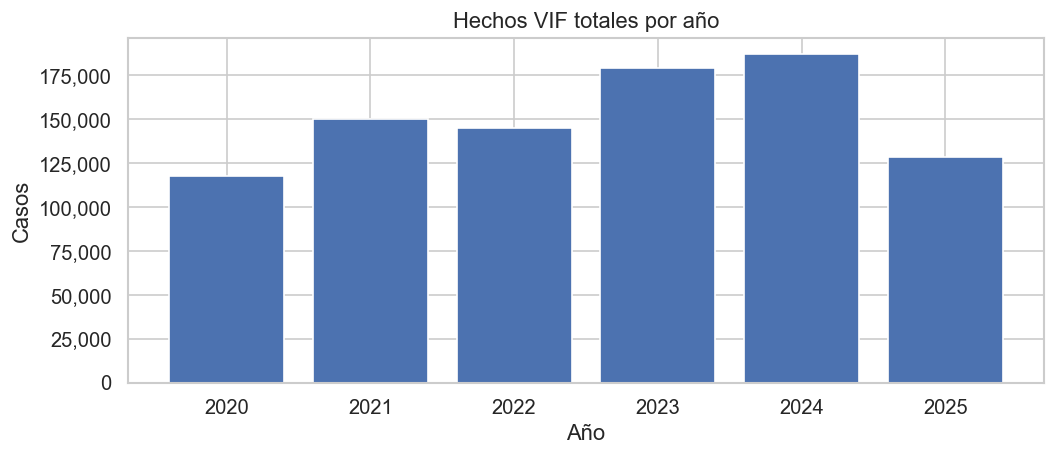

In [8]:
anio_cnt = df.groupby("anio")["cantidad"].sum().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(anio_cnt["anio"].astype(str), anio_cnt["cantidad"], color="#4C72B0")
ax.set_title("Hechos VIF totales por año")
ax.set_xlabel("Año"); ax.set_ylabel("Casos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout(); plt.show()


## 4 · Top 20 municipios con más casos

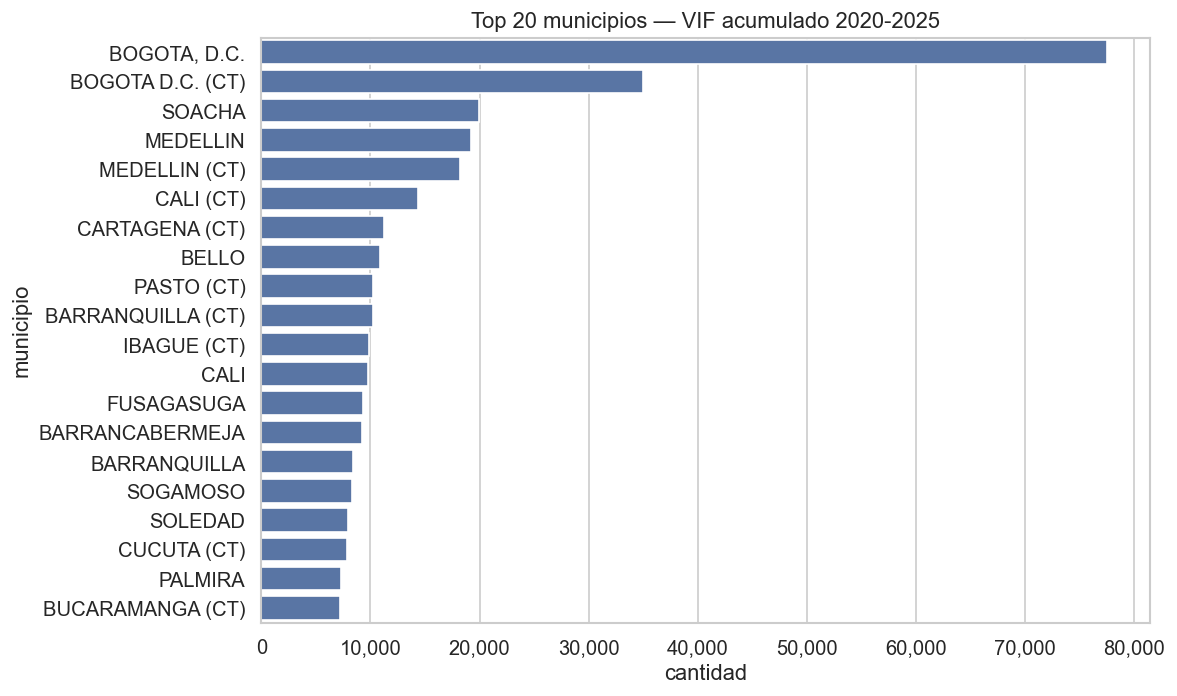

In [9]:
top_mun = (
    df.groupby("municipio")["cantidad"].sum()
    .nlargest(20).reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_mun, y="municipio", x="cantidad", ax=ax, color="#4C72B0")
ax.set_title("Top 20 municipios — VIF acumulado 2020-2025")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout(); plt.show()


## 5 · Distribución por departamento

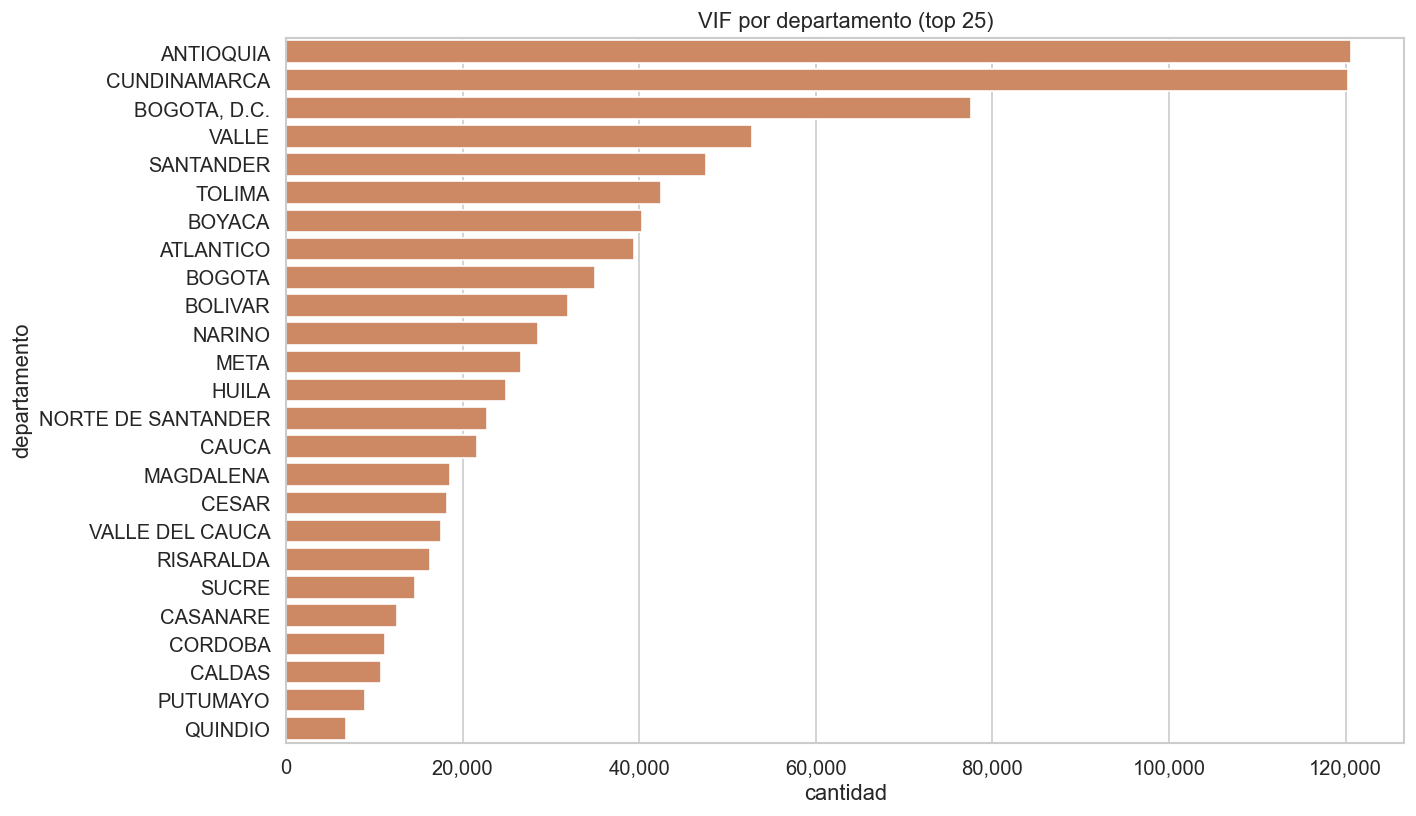

In [10]:
dep_cnt = (
    df.groupby("departamento")["cantidad"].sum()
    .sort_values(ascending=False).reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=dep_cnt.head(25), y="departamento", x="cantidad", ax=ax, color="#DD8452")
ax.set_title("VIF por departamento (top 25)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout(); plt.show()


## 6 · Heatmap municipio × año (top 15 municipios)

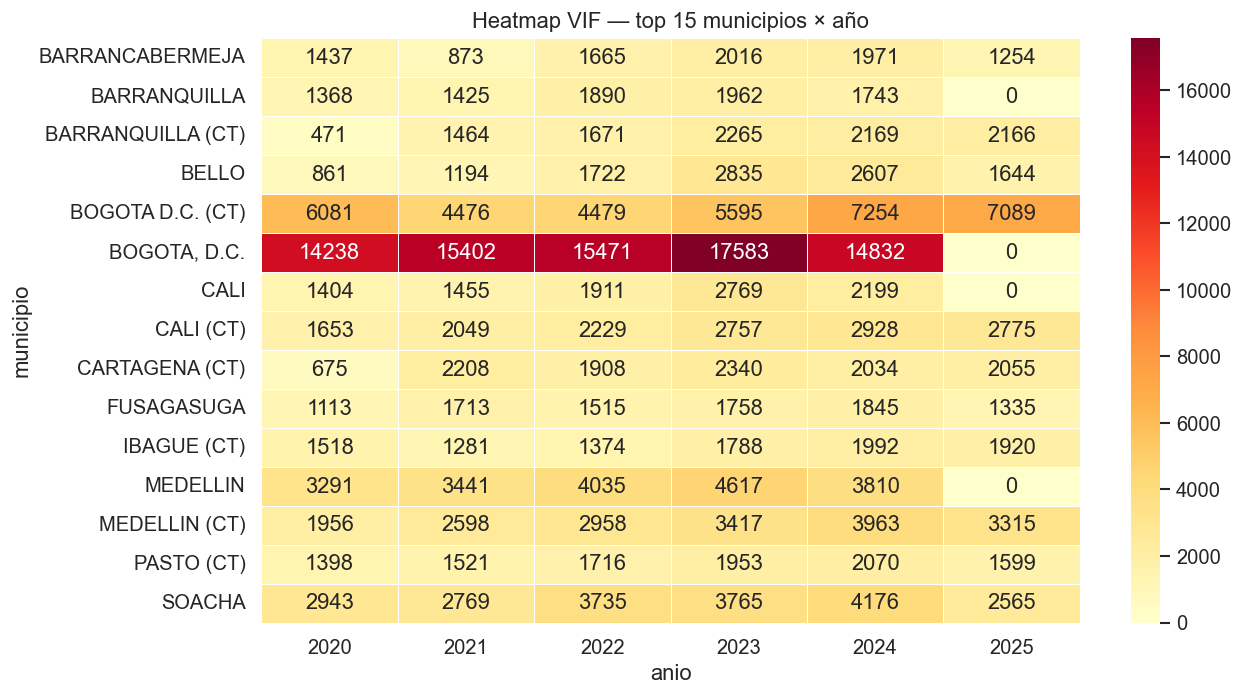

In [12]:
top15 = df.groupby("municipio")["cantidad"].sum().nlargest(15).index

pivot = (
    df[df["municipio"].isin(top15)]
    .pivot_table(
        index="municipio",
        columns="anio",
        values="cantidad",
        aggfunc="sum",
        fill_value=0
    )
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",   # 🔥 FIX AQUÍ
    cmap="YlOrRd",
    linewidths=0.4,
    ax=ax
)

ax.set_title("Heatmap VIF — top 15 municipios × año")
plt.tight_layout()
plt.show()

## 7 · Fuentes de datos

In [13]:
display(df["fuente"].value_counts().rename("registros").to_frame())


,registros
fuente,
Policia SIEDCO — VIF,608895
INMLCF — VIF Forense,296766


## 8 · Tendencia año a año (variación %)

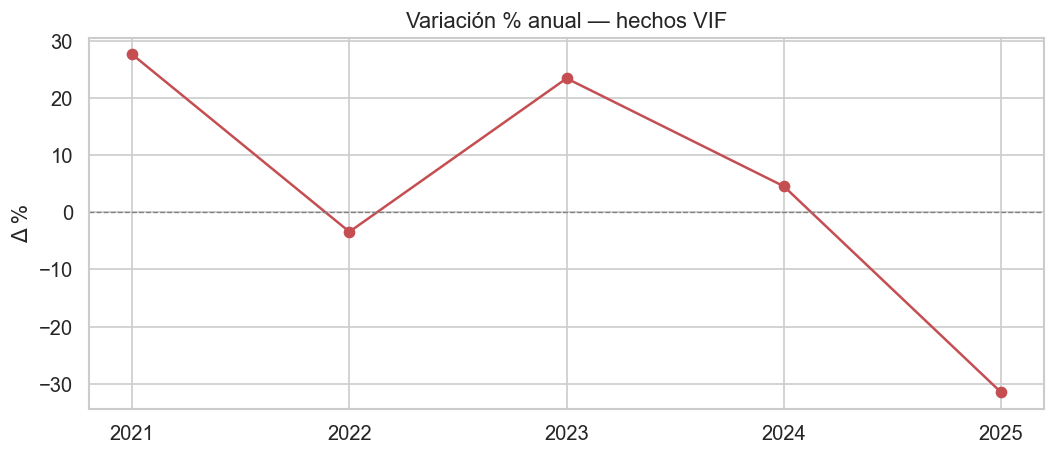

In [14]:
anio_cnt = anio_cnt.sort_values("anio")
anio_cnt["var_pct"] = anio_cnt["cantidad"].pct_change() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(anio_cnt["anio"].astype(str), anio_cnt["var_pct"], marker="o", color="#C44E52")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Variación % anual — hechos VIF")
ax.set_ylabel("Δ %")
plt.tight_layout(); plt.show()


## 9 · Exportar resumen